<a href="https://colab.research.google.com/github/DanielNazarioPro/CienciadeDados/blob/main/DataLake_JogosOlimpicos_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏅 Data Lake — Jogos Olímpicos (1896–2024)

Pipeline completo com **6 datasets** organizados em 3 camadas.

### Fontes de dados

| Arquivo | Fonte | Descrição |
|---------|-------|-----------|
| `world_olympedia_olympics_athlete_bio.csv` | Base dos Dados / Olympedia | Biografia dos atletas históricos |
| `world_olympedia_olympics_athlete_event_result.csv` | Base dos Dados / Olympedia | Resultados por atleta e evento |
| `world_olympedia_olympics_game_medal_tally.csv` | Base dos Dados / Olympedia | Quadro de medalhas por edição |
| `athletes.csv` | Kaggle — Paris 2024 | Atletas de Paris 2024 |
| `events.csv` | Kaggle — Paris 2024 | Eventos de Paris 2024 |
| `medals_total.csv` | Kaggle — Paris 2024 | Quadro de medalhas Paris 2024 |

### Pipeline
```
raw/  →  bronze/  →  gold/
```

---
- **Aluno:** Daniel Nazário Oliveira de Souza
- **Professor:** Luis Cueves Rodriguez

## 0. Instalações e Imports

In [ ]:
!pip install pyarrow -q

In [ ]:
import pandas as pd
import os
import json
import shutil
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import date
from IPython.display import display, HTML

print(' Imports OK')

 Imports OK


## 1. Upload dos Arquivos

Faça o upload dos **6 arquivos CSV**:

**Histórico (Base dos Dados / Olympedia):**
- `world_olympedia_olympics_athlete_bio.csv`
- `world_olympedia_olympics_athlete_event_result.csv`
- `world_olympedia_olympics_game_medal_tally.csv`

**Paris 2024 (Kaggle):**
- `athletes.csv`
- `events.csv`
- `medals_total.csv`

In [ ]:
from google.colab import files

print('Faça o upload dos 6 arquivos CSV:')
uploaded = files.upload()

print(f'\n {len(uploaded)} arquivo(s) recebido(s):')
for nome in sorted(uploaded.keys()):
    print(f'    {nome}')

Faça o upload dos 6 arquivos CSV:


Saving athletes.csv to athletes.csv
Saving events.csv to events.csv
Saving medals_total.csv to medals_total.csv

 3 arquivo(s) recebido(s):
    athletes.csv
    events.csv
    medals_total.csv


## 2. Criação da Estrutura de Diretórios

In [ ]:
ROOT = Path('olympics-datalake')

# Estrutura completa de diretórios
diretorios = [
    ROOT / 'raw',
    ROOT / 'bronze',
    ROOT / 'gold' / 'analise_medalhas',
    ROOT / 'gold' / 'analise_atletas',
    ROOT / 'gold' / 'analise_modalidades',
    ROOT / 'gold' / 'analise_genero',
]

for d in diretorios:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Estrutura criada:')
for root, dirs, _ in os.walk(ROOT):
    nivel = root.replace(str(ROOT), '').count(os.sep)
    print('│   ' * nivel + '├── ' + os.path.basename(root) + '/')

✅ Estrutura criada:
├── olympics-datalake/
│   ├── bronze/
│   ├── raw/
│   ├── gold/
│   │   ├── analise_modalidades/
│   │   ├── analise_medalhas/
│   │   ├── analise_genero/
│   │   ├── analise_atletas/


## 3. Camada RAW — Dados Brutos + Metadados JSON

Copia cada CSV para `raw/` e gera um `.json` de metadados correspondente.

In [ ]:

# Mapa de todos os datasets: nome_origem → configuração
DATASETS_RAW = {
    # ---------- HISTÓRICO ----------
    'world_olympedia_olympics_athlete_bio.csv': {
        'destino'       : 'hist_athlete_bio.csv',
        'nome_dataset'  : 'hist_athlete_bio',
        'fonte'         : 'Base dos Dados / Olympedia — https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b',
        'descricao'     : 'Dados biográficos dos atletas olímpicos históricos: nome, sexo, data de nascimento, altura, peso e país.',
        'periodo'       : '1896–2022',
        'observacoes'   : 'Muitos campos biográficos podem estar nulos para atletas antigos.',
        'campos'        : [
            {'nome': 'athlete_id',    'tipo': 'int',    'descricao': 'ID único do atleta'},
            {'nome': 'name',          'tipo': 'string', 'descricao': 'Nome do atleta'},
            {'nome': 'sex',           'tipo': 'string', 'descricao': 'Sexo (Male / Female)'},
            {'nome': 'birth_date',    'tipo': 'date',   'descricao': 'Data de nascimento'},
            {'nome': 'birth_year',    'tipo': 'int',    'descricao': 'Ano de nascimento'},
            {'nome': 'height',        'tipo': 'float',  'descricao': 'Altura em cm'},
            {'nome': 'weight',        'tipo': 'float',  'descricao': 'Peso em kg'},
            {'nome': 'country',       'tipo': 'string', 'descricao': 'Nome do país'},
            {'nome': 'country_noc',   'tipo': 'string', 'descricao': 'Código NOC (3 letras)'},
            {'nome': 'description',   'tipo': 'string', 'descricao': 'Descrição adicional'},
            {'nome': 'special_notes', 'tipo': 'string', 'descricao': 'Notas especiais'},
        ],
    },
    'world_olympedia_olympics_athlete_event_result.csv': {
        'destino'       : 'hist_athlete_event_result.csv',
        'nome_dataset'  : 'hist_athlete_event_result',
        'fonte'         : 'Base dos Dados / Olympedia — https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b',
        'descricao'     : 'Resultados individuais de cada atleta por evento e edição olímpica. Inclui posição, medalha conquistada e indicação de esporte coletivo.',
        'periodo'       : '1896–2022',
        'observacoes'   : 'Coluna medal pode ser nula (atleta sem medalha). is_team_sport indica se o evento é coletivo.',
        'campos'        : [
            {'nome': 'edition',      'tipo': 'string',  'descricao': 'Nome da edição (ex: 2020 Summer Olympics)'},
            {'nome': 'edition_id',   'tipo': 'int',     'descricao': 'ID da edição'},
            {'nome': 'country_noc',  'tipo': 'string',  'descricao': 'Código NOC do país representado'},
            {'nome': 'sport',        'tipo': 'string',  'descricao': 'Esporte'},
            {'nome': 'event',        'tipo': 'string',  'descricao': 'Evento específico'},
            {'nome': 'result_id',    'tipo': 'int',     'descricao': 'ID do resultado'},
            {'nome': 'athlete',      'tipo': 'string',  'descricao': 'Nome do atleta'},
            {'nome': 'athlete_id',   'tipo': 'int',     'descricao': 'ID do atleta'},
            {'nome': 'position',     'tipo': 'string',  'descricao': 'Posição final'},
            {'nome': 'medal',        'tipo': 'string',  'descricao': 'Medalha (Gold/Silver/Bronze ou nulo)'},
            {'nome': 'is_team_sport','tipo': 'boolean', 'descricao': 'True se for esporte coletivo'},
        ],
    },
    'world_olympedia_olympics_game_medal_tally.csv': {
        'destino'       : 'hist_game_medal_tally.csv',
        'nome_dataset'  : 'hist_game_medal_tally',
        'fonte'         : 'Base dos Dados / Olympedia — https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b',
        'descricao'     : 'Quadro de medalhas agregado por país e por edição olímpica. Cobre todos os Jogos de Verão e Inverno de 1896 a 2022.',
        'periodo'       : '1896–2022',
        'observacoes'   : 'A temporada (Summer/Winter) deve ser inferida da coluna edition. Dados já agregados por país por edição.',
        'campos'        : [
            {'nome': 'year',        'tipo': 'int',    'descricao': 'Ano da edição'},
            {'nome': 'edition',     'tipo': 'string', 'descricao': 'Nome completo da edição'},
            {'nome': 'edition_id',  'tipo': 'int',    'descricao': 'ID da edição'},
            {'nome': 'country',     'tipo': 'string', 'descricao': 'Nome do país'},
            {'nome': 'country_noc', 'tipo': 'string', 'descricao': 'Código NOC (3 letras)'},
            {'nome': 'gold',        'tipo': 'int',    'descricao': 'Medalhas de ouro'},
            {'nome': 'silver',      'tipo': 'int',    'descricao': 'Medalhas de prata'},
            {'nome': 'bronze',      'tipo': 'int',    'descricao': 'Medalhas de bronze'},
            {'nome': 'total',       'tipo': 'int',    'descricao': 'Total de medalhas'},
        ],
    },
    # ---------- PARIS 2024 ----------
    'athletes.csv': {
        'destino'       : 'paris2024_athletes.csv',
        'nome_dataset'  : 'paris2024_athletes',
        'fonte'         : 'Kaggle — Paris 2024 Olympic Summer Games — https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games',
        'descricao'     : 'Dados completos dos atletas participantes dos Jogos Olímpicos de Paris 2024, incluindo informações biográficas e pessoais.',
        'periodo'       : '2024 (Paris)',
        'observacoes'   : 'Contém informações ricas como hobbies, filosofia e parentes esportistas. Algumas colunas são texto livre.',
        'campos'        : [
            {'nome': 'code',          'tipo': 'int',    'descricao': 'ID do atleta'},
            {'nome': 'name',          'tipo': 'string', 'descricao': 'Nome completo'},
            {'nome': 'gender',        'tipo': 'string', 'descricao': 'Gênero (Male/Female)'},
            {'nome': 'country_code',  'tipo': 'string', 'descricao': 'Código NOC do país'},
            {'nome': 'country',       'tipo': 'string', 'descricao': 'Nome abreviado do país'},
            {'nome': 'disciplines',   'tipo': 'string', 'descricao': 'Modalidades disputadas'},
            {'nome': 'events',        'tipo': 'string', 'descricao': 'Eventos específicos'},
            {'nome': 'birth_date',    'tipo': 'date',   'descricao': 'Data de nascimento'},
            {'nome': 'height',        'tipo': 'float',  'descricao': 'Altura em metros'},
            {'nome': 'weight',        'tipo': 'float',  'descricao': 'Peso em kg'},
        ],
    },
    'events.csv': {
        'destino'       : 'paris2024_events.csv',
        'nome_dataset'  : 'paris2024_events',
        'fonte'         : 'Kaggle — Paris 2024 Olympic Summer Games — https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games',
        'descricao'     : 'Catálogo de todos os eventos disputados nos Jogos de Paris 2024, com esporte, código e URL oficial.',
        'periodo'       : '2024 (Paris)',
        'observacoes'   : 'Pode ser usado como tabela de dimensão para enriquecer os resultados.',
        'campos'        : [
            {'nome': 'event',      'tipo': 'string', 'descricao': 'Nome do evento'},
            {'nome': 'tag',        'tipo': 'string', 'descricao': 'Tag identificadora'},
            {'nome': 'sport',      'tipo': 'string', 'descricao': 'Nome do esporte'},
            {'nome': 'sport_code', 'tipo': 'string', 'descricao': 'Código do esporte (3 letras)'},
            {'nome': 'sport_url',  'tipo': 'string', 'descricao': 'URL oficial na página das Olimpíadas'},
        ],
    },
    'medals_total.csv': {
        'destino'       : 'paris2024_medals_total.csv',
        'nome_dataset'  : 'paris2024_medals_total',
        'fonte'         : 'Kaggle — Paris 2024 Olympic Summer Games — https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games',
        'descricao'     : 'Quadro total de medalhas dos Jogos de Paris 2024, agregado por país.',
        'periodo'       : '2024 (Paris)',
        'observacoes'   : 'Apenas Jogos de Verão. Deve ser integrado ao histórico para análise completa.',
        'campos'        : [
            {'nome': 'country_code', 'tipo': 'string', 'descricao': 'Código NOC (3 letras)'},
            {'nome': 'country',      'tipo': 'string', 'descricao': 'Nome abreviado do país'},
            {'nome': 'country_long', 'tipo': 'string', 'descricao': 'Nome completo do país'},
            {'nome': 'Gold Medal',   'tipo': 'int',    'descricao': 'Medalhas de ouro'},
            {'nome': 'Silver Medal', 'tipo': 'int',    'descricao': 'Medalhas de prata'},
            {'nome': 'Bronze Medal', 'tipo': 'int',    'descricao': 'Medalhas de bronze'},
            {'nome': 'Total',        'tipo': 'int',    'descricao': 'Total de medalhas'},
        ],
    },
}

print(f'✅ {len(DATASETS_RAW)} datasets configurados')

✅ 6 datasets configurados


In [ ]:

# Copiar todos os CSVs para raw/ e gerar metadados JSON
RAW = ROOT / 'raw'
dataframes_raw = {}   # armazena todos os DataFrames para uso posterior

for arquivo_origem, cfg in DATASETS_RAW.items():
    destino_csv  = RAW / cfg['destino']
    destino_json = RAW / cfg['destino'].replace('.csv', '.json')

    # Copiar CSV
    shutil.copy(arquivo_origem, destino_csv)

    # Carregar para inspeção
    df = pd.read_csv(destino_csv, low_memory=False)
    dataframes_raw[cfg['nome_dataset']] = df

    # Gerar metadados
    meta = {
        'nome_dataset'       : cfg['nome_dataset'],
        'arquivo_origem'     : arquivo_origem,
        'fonte'              : cfg['fonte'],
        'descricao'          : cfg['descricao'],
        'campos_principais'  : cfg['campos'],
        'periodo_coberto'    : cfg['periodo'],
        'formato'            : 'CSV',
        'delimitador'        : ',',
        'codificacao'        : 'utf-8',
        'quantidade_linhas'  : len(df),
        'quantidade_colunas' : len(df.columns),
        'colunas_reais'      : df.columns.tolist(),
        'data_coleta'        : str(date.today()),
        'camada'             : 'raw',
        'caminho'            : str(destino_csv),
        'observacoes'        : cfg['observacoes'],
        'versao'             : '1.0',
    }
    with open(destino_json, 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=4)

    print(f'✅ {cfg["nome_dataset"]:45s} → {len(df):>7,} linhas × {len(df.columns)} colunas')

print('\n📁 raw/ pronta!')

✅ hist_athlete_bio                              → 155,861 linhas × 11 colunas
✅ hist_athlete_event_result                     → 316,834 linhas × 11 colunas
✅ hist_game_medal_tally                         →   1,807 linhas × 9 colunas
✅ paris2024_athletes                            →  11,113 linhas × 36 colunas
✅ paris2024_events                              →     329 linhas × 5 colunas
✅ paris2024_medals_total                        →      92 linhas × 7 colunas

📁 raw/ pronta!


## 4. Camada BRONZE — Padronização, Parquet e Integração (JOINs)

### 4.1 Padronizar cada dataset individualmente

In [ ]:
BRONZE = ROOT / 'bronze'

# ── Histórico: Athlete Bio
df_bio = dataframes_raw['hist_athlete_bio'].copy()
df_bio = df_bio.rename(columns={'country_noc': 'NOC', 'country': 'country_name'})
df_bio['fonte'] = 'historico'
print(f' athlete_bio padronizado:  {df_bio.shape}')

# ── Histórico: Athlete Event Result
df_results = dataframes_raw['hist_athlete_event_result'].copy()
df_results = df_results.rename(columns={'country_noc': 'NOC'})
df_results['season'] = df_results['edition'].apply(
    lambda x: 'Winter' if 'Winter' in str(x) else 'Summer'
)
print(f' athlete_event_result padr.: {df_results.shape}')

# ── Histórico: Medal Tally
df_tally = dataframes_raw['hist_game_medal_tally'].copy()
df_tally = df_tally.rename(columns={
    'country_noc': 'NOC', 'country': 'country_name',
    'gold': 'Gold', 'silver': 'Silver', 'bronze': 'Bronze', 'total': 'Total'
})
df_tally['season'] = df_tally['edition'].apply(
    lambda x: 'Winter' if 'Winter' in str(x) else 'Summer'
)
print(f' game_medal_tally padron.:  {df_tally.shape}')

# ── Paris 2024: Athletes
df_p24_ath = dataframes_raw['paris2024_athletes'].copy()
df_p24_ath = df_p24_ath.rename(columns={
    'code': 'athlete_id', 'country_code': 'NOC',
    'gender': 'sex', 'country_long': 'country_name'
})
df_p24_ath['fonte'] = 'paris2024'
print(f' paris2024_athletes padron.: {df_p24_ath.shape}')

# ── Paris 2024: Events
df_p24_evt = dataframes_raw['paris2024_events'].copy()
print(f' paris2024_events padron.:   {df_p24_evt.shape}')

# ── Paris 2024: Medals Total
df_p24_med = dataframes_raw['paris2024_medals_total'].copy()
df_p24_med = df_p24_med.rename(columns={
    'country_code': 'NOC', 'country_long': 'country_name',
    'Gold Medal': 'Gold', 'Silver Medal': 'Silver', 'Bronze Medal': 'Bronze'
})
df_p24_med['year']       = 2024
df_p24_med['edition']    = '2024 Summer Olympics'
df_p24_med['edition_id'] = 0
df_p24_med['season']     = 'Summer'
print(f' paris2024_medals padron.:   {df_p24_med.shape}')

 athlete_bio padronizado:  (155861, 12)
 athlete_event_result padr.: (316834, 12)
 game_medal_tally padron.:  (1807, 10)
 paris2024_athletes padron.: (11113, 37)
 paris2024_events padron.:   (329, 5)
 paris2024_medals padron.:   (92, 11)


In [ ]:

# Salvar cada dataset padronizado em Parquet
datasets_bronze_individuais = {
    'hist_athlete_bio'          : df_bio,
    'hist_athlete_event_result' : df_results,
    'hist_game_medal_tally'     : df_tally,
    'paris2024_athletes'        : df_p24_ath,
    'paris2024_events'          : df_p24_evt,
    'paris2024_medals_total'    : df_p24_med,
}

for nome, df in datasets_bronze_individuais.items():
    caminho = BRONZE / f'{nome}.parquet'
    df.to_parquet(caminho, engine='pyarrow', index=False)
    print(f' {nome}.parquet  ({len(df):,} linhas)')

print('\n Parquets individuais salvos na bronze/')

 hist_athlete_bio.parquet  (155,861 linhas)
 hist_athlete_event_result.parquet  (316,834 linhas)
 hist_game_medal_tally.parquet  (1,807 linhas)
 paris2024_athletes.parquet  (11,113 linhas)
 paris2024_events.parquet  (329 linhas)
 paris2024_medals_total.parquet  (92 linhas)

 Parquets individuais salvos na bronze/


### 4.2 Integração (JOINs) — Datasets consolidados

In [ ]:

# JOIN 1: Quadro de Medalhas Unificado (1896–2024)
# hist_game_medal_tally  UNION  paris2024_medals_total

cols_tally = ['year', 'edition', 'edition_id', 'country_name', 'NOC',
              'Gold', 'Silver', 'Bronze', 'Total', 'season']

# Paris 2024 no mesmo formato
df_p24_tally = df_p24_med[['year','edition','edition_id','country_name',
                            'NOC','Gold','Silver','Bronze','Total','season']].copy()

df_medalhas_unif = pd.concat(
    [df_tally[cols_tally], df_p24_tally], ignore_index=True
)
for col in ['Gold','Silver','Bronze','Total','year']:
    df_medalhas_unif[col] = pd.to_numeric(df_medalhas_unif[col], errors='coerce').fillna(0).astype(int)

print(f'✅ Medalhas unificadas (1896–2024): {df_medalhas_unif.shape}')
print(f'   Edições: {df_medalhas_unif["edition"].nunique()}')
print(f'   Países:  {df_medalhas_unif["NOC"].nunique()}')
print(df_medalhas_unif.head(3))

✅ Medalhas unificadas (1896–2024): (1899, 10)
   Edições: 56
   Países:  160
   year               edition  edition_id   country_name  NOC  Gold  Silver  \
0  1896  1896 Summer Olympics           1         Greece  GRE    10      18   
1  1900  1900 Summer Olympics           2         France  FRA    31      41   
2  1900  1900 Summer Olympics           2  United States  USA    20      13   

   Bronze  Total  season  
0      19     47  Summer  
1      40    112  Summer  
2      15     48  Summer  


In [ ]:

# JOIN 2: Resultados por Atleta Enriquecidos
# hist_athlete_event_result  LEFT JOIN  hist_athlete_bio
# (adiciona sexo, ano de nascimento e altura ao resultado)

bio_cols = ['athlete_id', 'sex', 'birth_year', 'height', 'weight']

df_results_enrich = df_results.merge(
    df_bio[bio_cols],
    on='athlete_id',
    how='left'
)

print(f' Resultados enriquecidos: {df_results_enrich.shape}')
print(df_results_enrich.head(3))

 Resultados enriquecidos: (316834, 16)
                edition  edition_id  NOC     sport          event  result_id  \
0  1928 Winter Olympics          30  SUI  Skeleton  Skeleton, Men          1   
1  1928 Winter Olympics          30  FRA  Skeleton  Skeleton, Men          1   
2  1928 Winter Olympics          30  FRA  Skeleton  Skeleton, Men          1   

                   athlete  athlete_id        position medal  is_team_sport  \
0         Willy von Eschen       98710  Did not finish   NaN          False   
1  Jean, Comte de Beaumont       42118   Did not start   NaN          False   
2          Pierre Dormeuil       85267  Did not finish   NaN          False   

   season   sex  birth_year  height  weight  
0  Winter  Male      1902.0     NaN     NaN  
1  Winter  Male      1904.0     NaN     NaN  
2  Winter  Male      1887.0   198.0    88.0  


In [ ]:

# JOIN 3: Atletas Paris 2024 + Catálogo de Eventos
# paris2024_athletes  explode  disciplines  LEFT JOIN  paris2024_events

import ast

# Extrair primeira disciplina listada para cada atleta
def extrair_primeira(valor):
    try:
        lista = ast.literal_eval(str(valor))
        return lista[0] if lista else None
    except:
        return None

df_p24_ath_evt = df_p24_ath.copy()
df_p24_ath_evt['sport_principal'] = df_p24_ath_evt['disciplines'].apply(extrair_primeira)

df_atletas_eventos = df_p24_ath_evt[['athlete_id','name','sex','NOC','country_name',
                                     'birth_date','sport_principal']].merge(
    df_p24_evt[['sport','sport_code']].drop_duplicates(),
    left_on='sport_principal', right_on='sport',
    how='left'
)

print(f' Atletas Paris 2024 + Eventos: {df_atletas_eventos.shape}')
print(df_atletas_eventos.head(3))

 Atletas Paris 2024 + Eventos: (11113, 9)
   athlete_id              name   sex  NOC country_name  birth_date  \
0     1532872  ALEKSANYAN Artur  Male  ARM      Armenia  1991-10-21   
1     1532873    AMOYAN Malkhas  Male  ARM      Armenia  1999-01-22   
2     1532874   GALSTYAN Slavik  Male  ARM      Armenia  1996-12-21   

  sport_principal      sport sport_code  
0       Wrestling  Wrestling        WRE  
1       Wrestling  Wrestling        WRE  
2       Wrestling  Wrestling        WRE  


In [ ]:

# Salvar JOINs em CSV + Parquet na bronze/

joins = {
    'medalhas_1896_2024'      : df_medalhas_unif,
    'resultados_enriquecidos' : df_results_enrich,
    'atletas_paris2024_eventos': df_atletas_eventos,
}

for nome, df in joins.items():
    df.to_csv(    BRONZE / f'{nome}.csv',     index=False)
    df.to_parquet(BRONZE / f'{nome}.parquet', engine='pyarrow', index=False)
    print(f'✅ {nome}  ({len(df):,} linhas)')

print('\n JOINs salvos na bronze/')

✅ medalhas_1896_2024  (1,899 linhas)
✅ resultados_enriquecidos  (316,834 linhas)
✅ atletas_paris2024_eventos  (11,113 linhas)

 JOINs salvos na bronze/


In [ ]:

# Metadados dos JOINs na bronze/

metas_bronze = [
    {
        'nome_dataset'      : 'medalhas_1896_2024',
        'descricao'         : 'Quadro de medalhas unificado por país e edição, cobrindo todos os Jogos de Verão e Inverno de 1896 a 2024.',
        'operacao'          : 'UNION ALL entre hist_game_medal_tally e paris2024_medals_total após padronização de colunas',
        'fontes_origem'     : ['raw/hist_game_medal_tally.csv', 'raw/paris2024_medals_total.csv'],
        'colunas_chave'     : ['NOC', 'edition', 'season'],
        'quantidade_linhas' : len(df_medalhas_unif),
    },
    {
        'nome_dataset'      : 'resultados_enriquecidos',
        'descricao'         : 'Resultados históricos por atleta e evento, enriquecidos com dados biográficos (sexo, ano de nascimento, altura, peso).',
        'operacao'          : 'LEFT JOIN entre hist_athlete_event_result e hist_athlete_bio pela chave athlete_id',
        'fontes_origem'     : ['raw/hist_athlete_event_result.csv', 'raw/hist_athlete_bio.csv'],
        'colunas_chave'     : ['athlete_id', 'edition', 'event'],
        'quantidade_linhas' : len(df_results_enrich),
    },
    {
        'nome_dataset'      : 'atletas_paris2024_eventos',
        'descricao'         : 'Atletas de Paris 2024 com o código do esporte principal associado via catálogo de eventos.',
        'operacao'          : 'LEFT JOIN entre paris2024_athletes e paris2024_events pela coluna sport',
        'fontes_origem'     : ['raw/paris2024_athletes.csv', 'raw/paris2024_events.csv'],
        'colunas_chave'     : ['athlete_id', 'sport_principal'],
        'quantidade_linhas' : len(df_atletas_eventos),
    },
]

for meta in metas_bronze:
    meta.update({
        'formato'            : ['CSV', 'Parquet'],
        'data_processamento' : str(date.today()),
        'camada'             : 'bronze',
        'versao'             : '1.0',
    })
    caminho_json = BRONZE / f"{meta['nome_dataset']}.json"
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=4)
    print(f" Metadados: {caminho_json.name}")

print('\n Metadados bronze/ salvos!')

 Metadados: medalhas_1896_2024.json
 Metadados: resultados_enriquecidos.json
 Metadados: atletas_paris2024_eventos.json

 Metadados bronze/ salvos!


## 5. Camada GOLD — Análises Finais e Visualizações

### 5.1 Quadro de Medalhas (formato Wikipédia)

In [ ]:
GOLD_MED = ROOT / 'gold' / 'analise_medalhas'

# Agregar por NOC e temporada
summer = (
    df_medalhas_unif[df_medalhas_unif['season'] == 'Summer']
    .groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
    .rename(columns={'Gold':'S_Gold','Silver':'S_Silver','Bronze':'S_Bronze','Total':'S_Total'})
)
winter = (
    df_medalhas_unif[df_medalhas_unif['season'] == 'Winter']
    .groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
    .rename(columns={'Gold':'W_Gold','Silver':'W_Silver','Bronze':'W_Bronze','Total':'W_Total'})
)

df_quadro = summer.join(winter, how='outer').fillna(0).astype(int)
df_quadro['T_Gold']   = df_quadro['S_Gold']   + df_quadro['W_Gold']
df_quadro['T_Silver'] = df_quadro['S_Silver']  + df_quadro['W_Silver']
df_quadro['T_Bronze'] = df_quadro['S_Bronze']  + df_quadro['W_Bronze']
df_quadro['T_Total']  = df_quadro['S_Total']   + df_quadro['W_Total']

df_quadro = df_quadro.sort_values(['T_Total','T_Gold','T_Silver'], ascending=False).reset_index()
df_quadro.index += 1

print(f' Quadro de medalhas: {df_quadro.shape}')
print(df_quadro.head(5))

 Quadro de medalhas: (160, 13)
   NOC  S_Gold  S_Silver  S_Bronze  S_Total  W_Gold  W_Silver  W_Bronze  \
1  USA    1122       891       792     2805     113       122        95   
2  URS     395       319       296     1010      78        57        59   
3  GER     255       286       304      845     112       104        70   
4  GBR     314       356       349     1019      12         5        17   
5  FRA     262       292       323      877      41        42        55   

   W_Total  T_Gold  T_Silver  T_Bronze  T_Total  
1      330    1235      1013       887     3135  
2      194     473       376       355     1204  
3      286     367       390       374     1131  
4       34     326       361       366     1053  
5      138     303       334       378     1015  


In [ ]:
# ── Exibir tabela no formato Wikipédia (HTML) ─────────
def display_wikipedia_table(df, top_n=50):
    df_show = df.head(top_n).copy()
    df_show.insert(0, '#', range(1, len(df_show)+1))
    html = '''
    <style>
      .wt{border-collapse:collapse;font-family:Arial,sans-serif;font-size:12px;width:100%}
      .wt th{background:#CFE2F3;border:1px solid #aaa;padding:6px 8px;text-align:center}
      .wt td{border:1px solid #ddd;padding:4px 8px;text-align:center}
      .wt tr:nth-child(even){background:#f9f9f9}
      .wt tr:hover{background:#eef4fb}
      .cp{text-align:left!important;font-weight:bold}
      .cs{background:#FFFDE7} .cw{background:#E3F2FD} .ct{background:#E8F5E9;font-weight:bold}
    </style>
    <table class="wt">
      <thead>
        <tr>
          <th rowspan="2">#</th><th rowspan="2">País (NOC)</th>
          <th colspan="4" class="cs">☀️ Jogos de Verão</th>
          <th colspan="4" class="cw">❄️ Jogos de Inverno</th>
          <th colspan="4" class="ct">🏅 Total Geral</th>
        </tr>
        <tr>
          <th class="cs">🥇</th><th class="cs">🥈</th><th class="cs">🥉</th><th class="cs">T</th>
          <th class="cw">🥇</th><th class="cw">🥈</th><th class="cw">🥉</th><th class="cw">T</th>
          <th class="ct">🥇</th><th class="ct">🥈</th><th class="ct">🥉</th><th class="ct">T</th>
        </tr>
      </thead><tbody>'''
    for _, row in df_show.iterrows():
        html += '<tr>'
        html += f'<td>{int(row["#"])}</td><td class="cp">{row["NOC"]}</td>'
        for c in ['S_Gold','S_Silver','S_Bronze','S_Total']:
            html += f'<td class="cs">{int(row[c])}</td>'
        for c in ['W_Gold','W_Silver','W_Bronze','W_Total']:
            html += f'<td class="cw">{int(row[c])}</td>'
        for c in ['T_Gold','T_Silver','T_Bronze','T_Total']:
            html += f'<td class="ct">{int(row[c])}</td>'
        html += '</tr>'
    html += '</tbody></table>'
    display(HTML(html))

print('\n📊 QUADRO DE MEDALHAS OLÍMPICAS (Top 50) — Formato Wikipédia')
display_wikipedia_table(df_quadro, top_n=50)


📊 QUADRO DE MEDALHAS OLÍMPICAS (Top 50) — Formato Wikipédia


In [ ]:
# ── Tabelas individuais por categoria ─────────────────
def display_ranking_table(df_base, season=None, label='', emoji='🏅', top_n=50):
    df_f = df_base if season is None else df_base[df_base['season'] == season]
    df_f = (
        df_f.groupby('NOC')[['Gold','Silver','Bronze','Total']].sum()
        .sort_values(['Total','Gold','Silver'], ascending=False)
        .reset_index().head(top_n)
    )
    html = f'''
    <h3>{emoji} {label} (Top {top_n})</h3>
    <style>
      .rt{{border-collapse:collapse;font-family:Arial,sans-serif;font-size:12px}}
      .rt th{{background:#CFE2F3;border:1px solid #aaa;padding:6px 10px}}
      .rt td{{border:1px solid #ddd;padding:4px 10px;text-align:center}}
      .rt tr:nth-child(even){{background:#f9f9f9}}
      .rtp{{text-align:left!important;font-weight:bold}}
    </style>
    <table class="rt">
      <thead><tr><th>#</th><th>País</th><th>🥇</th><th>🥈</th><th>🥉</th><th>Total</th></tr></thead>
      <tbody>'''
    for i, (_, row) in enumerate(df_f.iterrows(), 1):
        html += f'<tr><td>{i}</td><td class="rtp">{row["NOC"]}</td><td>{int(row["Gold"])}</td><td>{int(row["Silver"])}</td><td>{int(row["Bronze"])}</td><td><b>{int(row["Total"])}</b></td></tr>'
    html += '</tbody></table><br>'
    display(HTML(html))
    return df_f

tbl_summer = display_ranking_table(df_medalhas_unif, 'Summer', 'Medalhas — Jogos de Verão',   '☀️')
tbl_winter = display_ranking_table(df_medalhas_unif, 'Winter', 'Medalhas — Jogos de Inverno', '❄️')
tbl_total  = display_ranking_table(df_medalhas_unif, None,     'Medalhas — Total Geral',      '🏅')

#,País,🥇,🥈,🥉,Total
1,USA,1122,891,792,2805
2,GBR,314,356,349,1019
3,URS,395,319,296,1010
4,FRA,262,292,323,877
5,GER,255,286,304,845
6,CHN,303,226,198,727
7,ITA,241,214,233,688
8,AUS,180,189,228,597
9,HUN,190,168,186,544
10,JPN,189,162,193,544


#,País,🥇,🥈,🥉,Total
1,NOR,148,134,123,405
2,USA,113,122,95,330
3,GER,112,104,70,286
4,AUT,71,88,91,250
5,CAN,77,72,76,225
6,URS,78,57,59,194
7,SWE,65,51,60,176
8,FIN,45,65,65,175
9,SUI,63,47,58,168
10,NED,53,49,45,147


#,País,🥇,🥈,🥉,Total
1,USA,1235,1013,887,3135
2,URS,473,376,355,1204
3,GER,367,390,374,1131
4,GBR,326,361,366,1053
5,FRA,303,334,378,1015
6,ITA,283,257,289,829
7,CHN,325,258,221,804
8,SWE,220,237,251,708
9,JPN,206,190,224,620
10,AUS,186,196,234,616


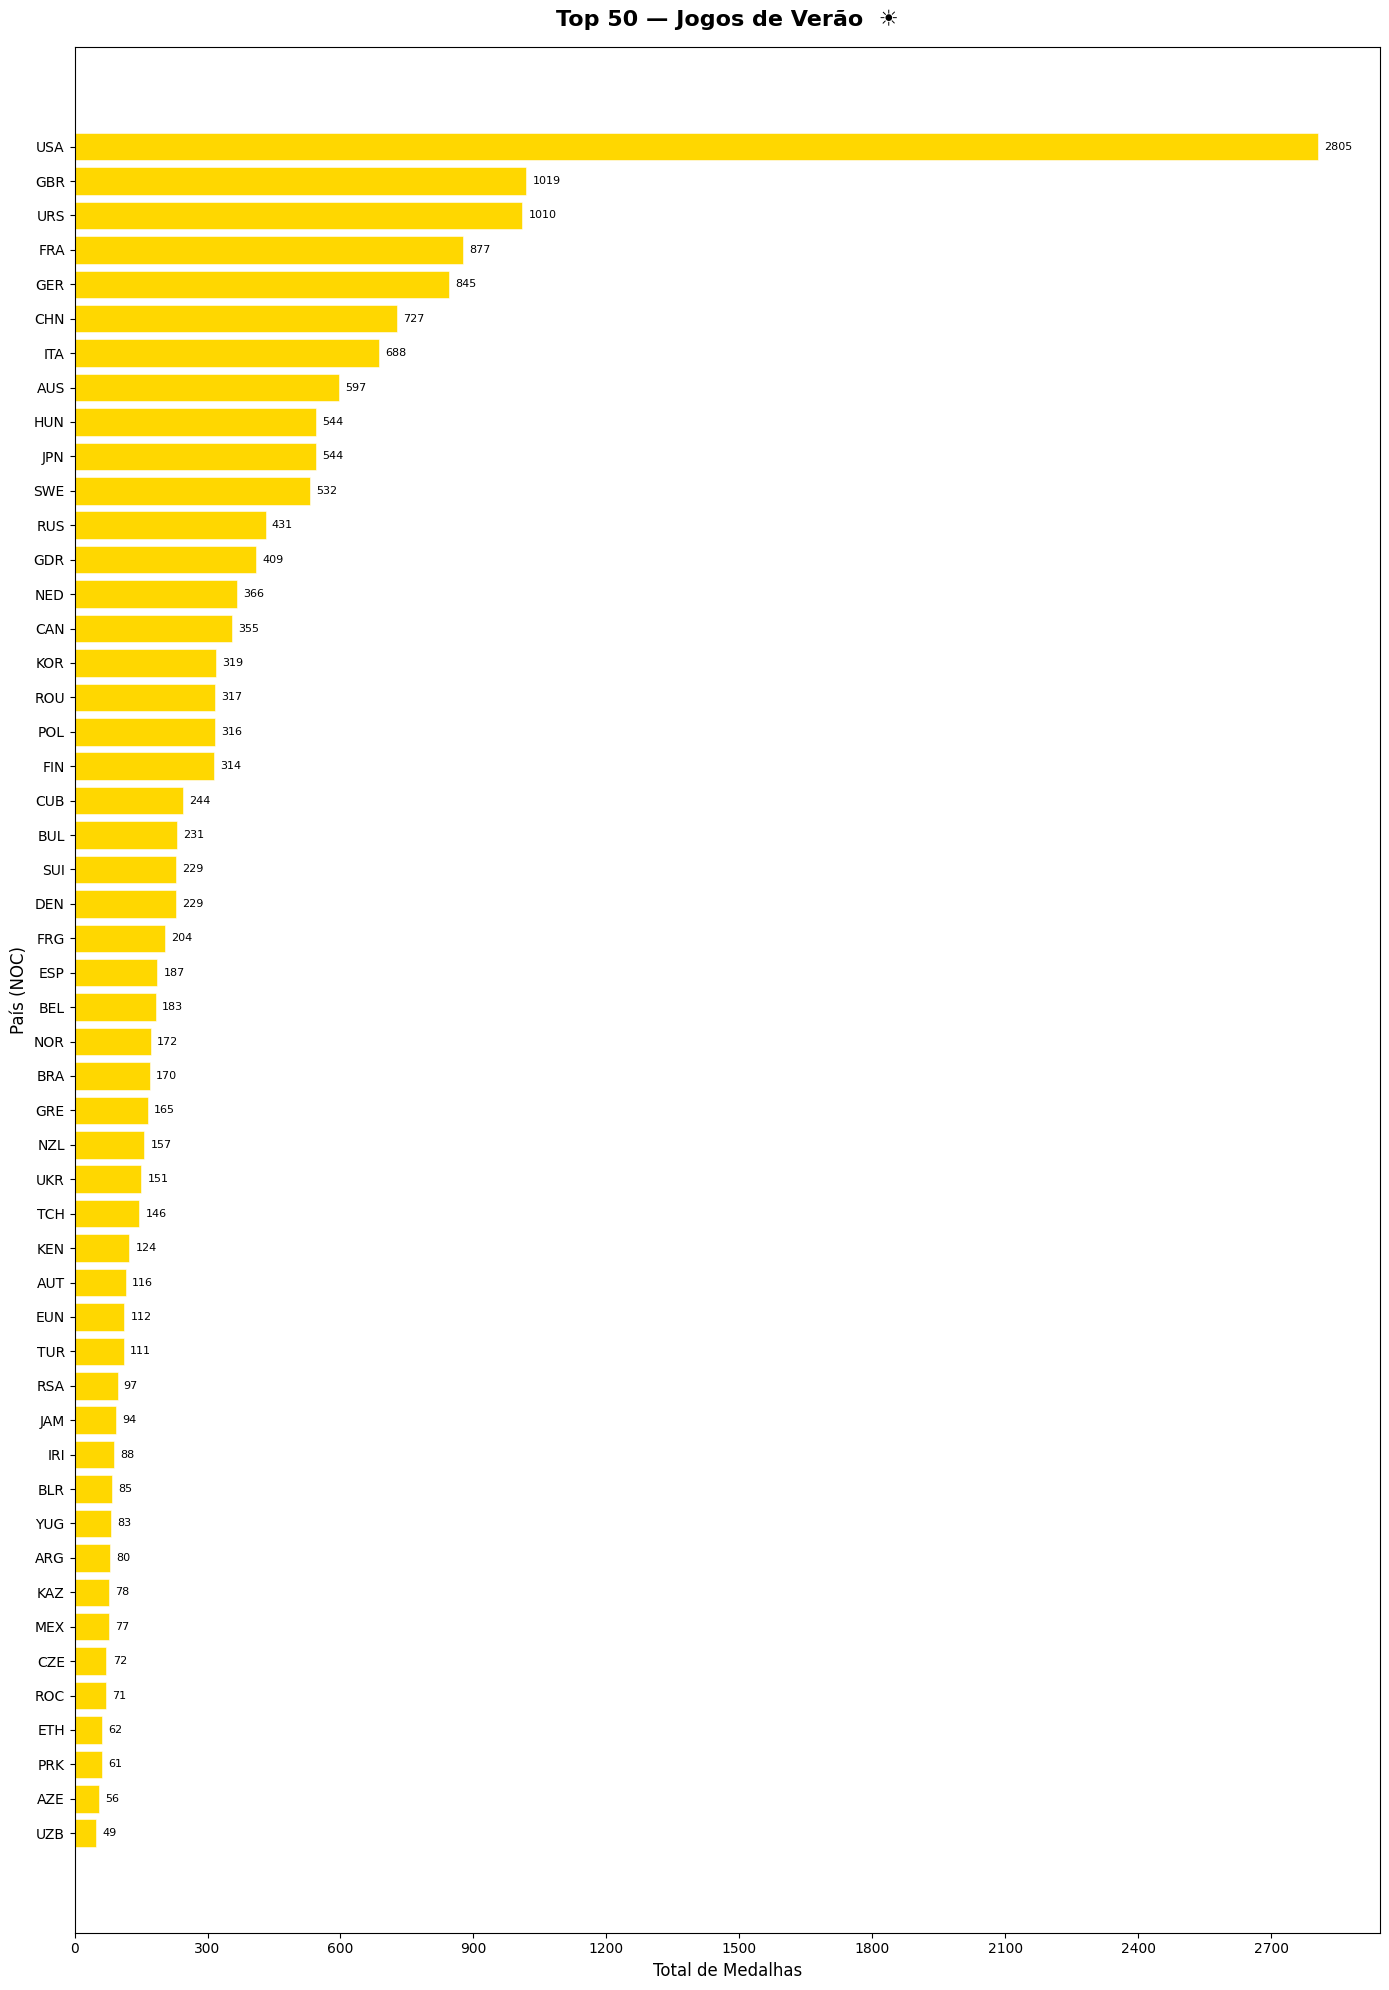

✅ Gráfico salvo: olympics-datalake/gold/analise_medalhas/top50_verao.png


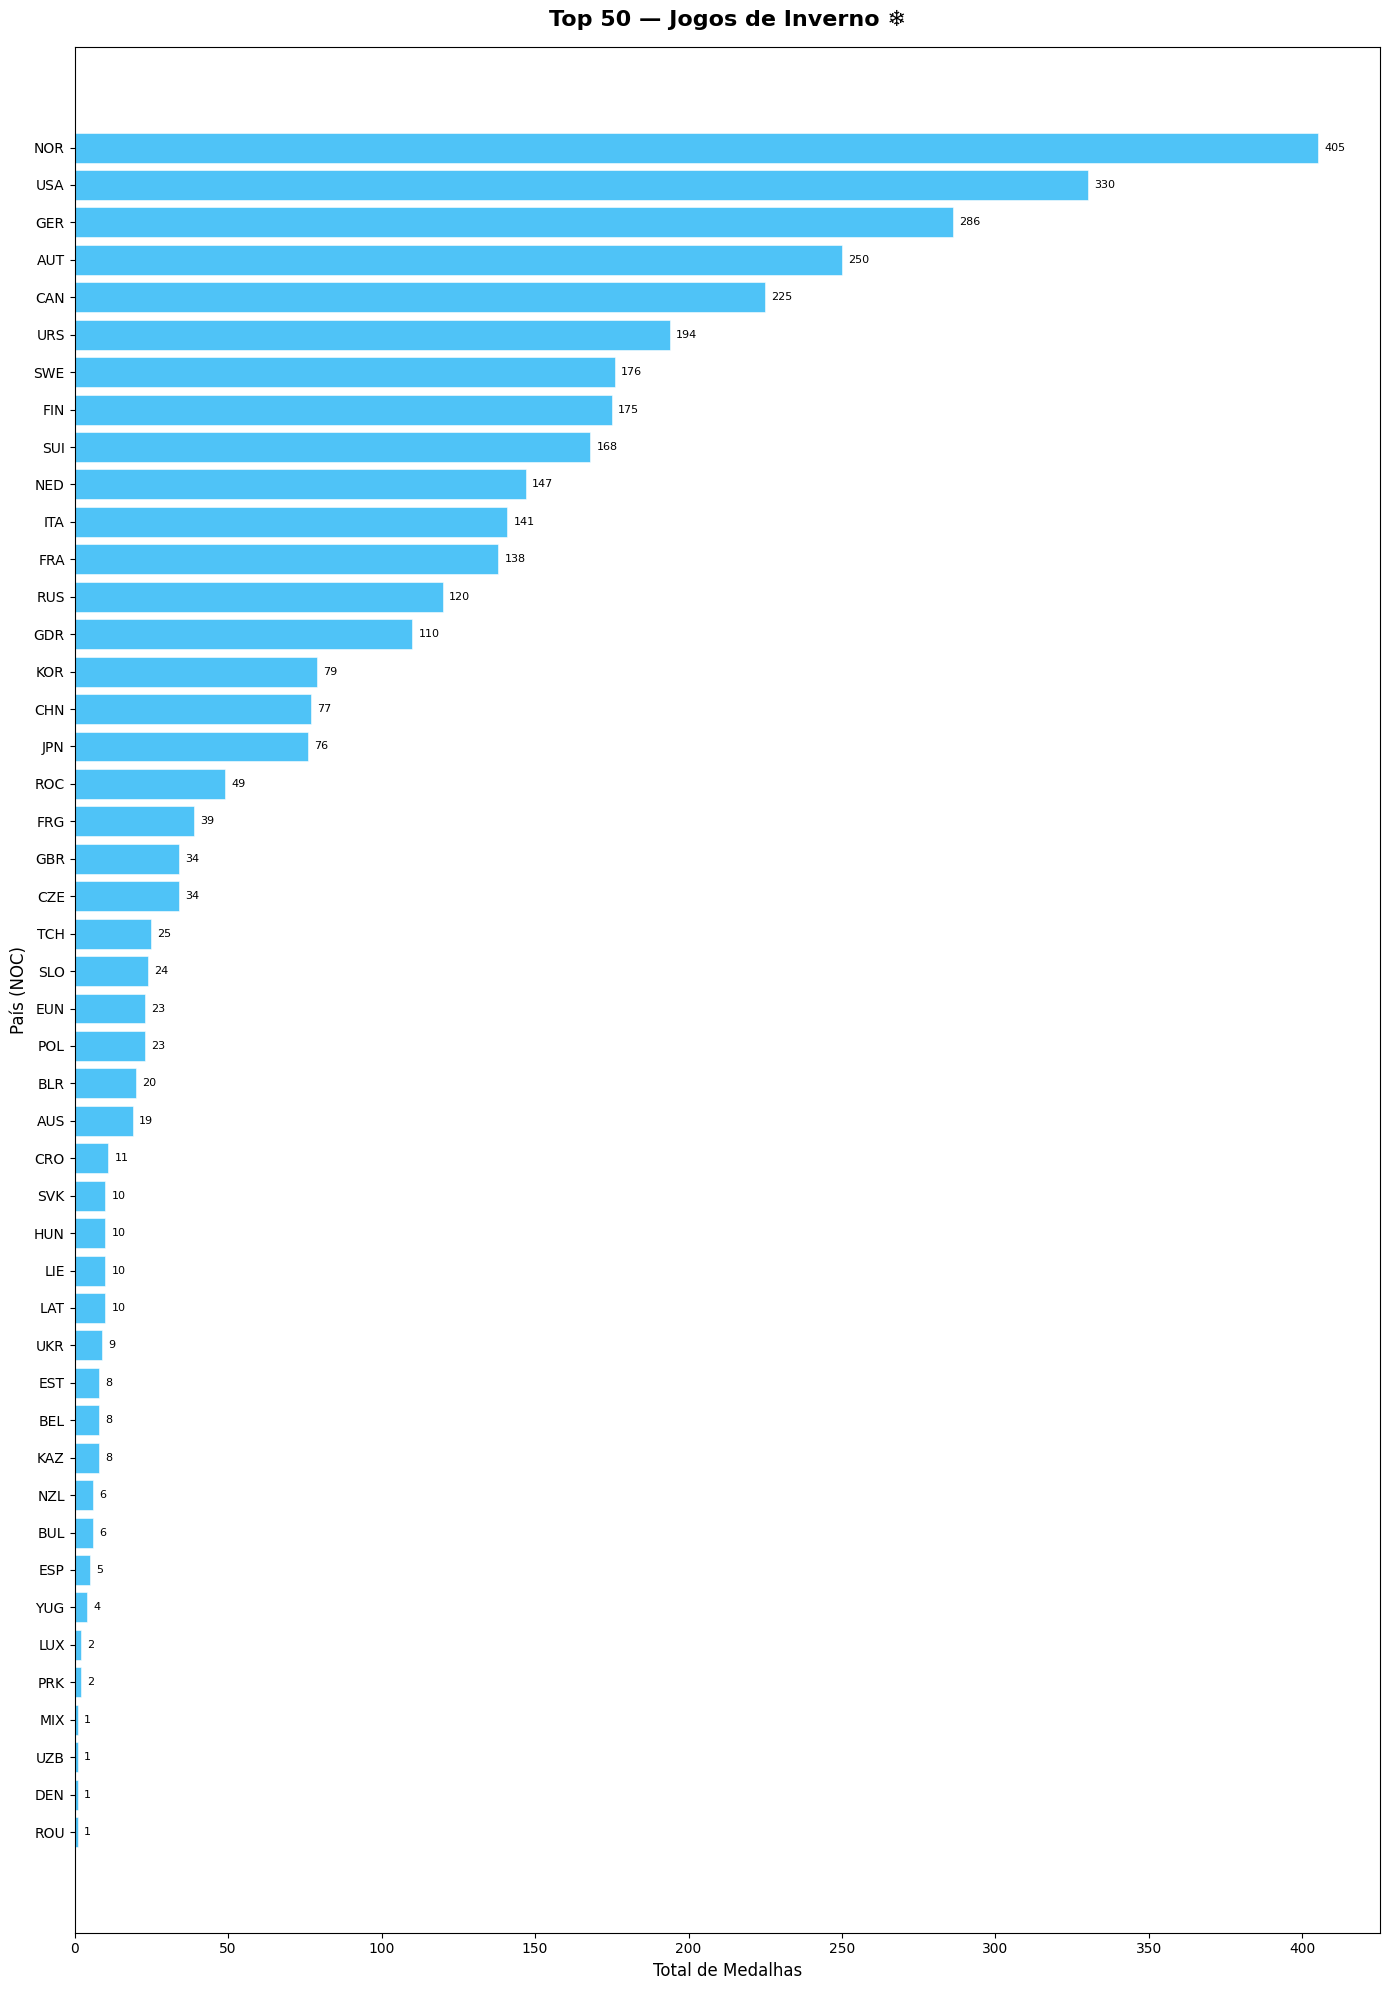

✅ Gráfico salvo: olympics-datalake/gold/analise_medalhas/top50_inverno.png


/tmp/ipykernel_10429/3434836609.py:15: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10429/3434836609.py:17: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig(caminho, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


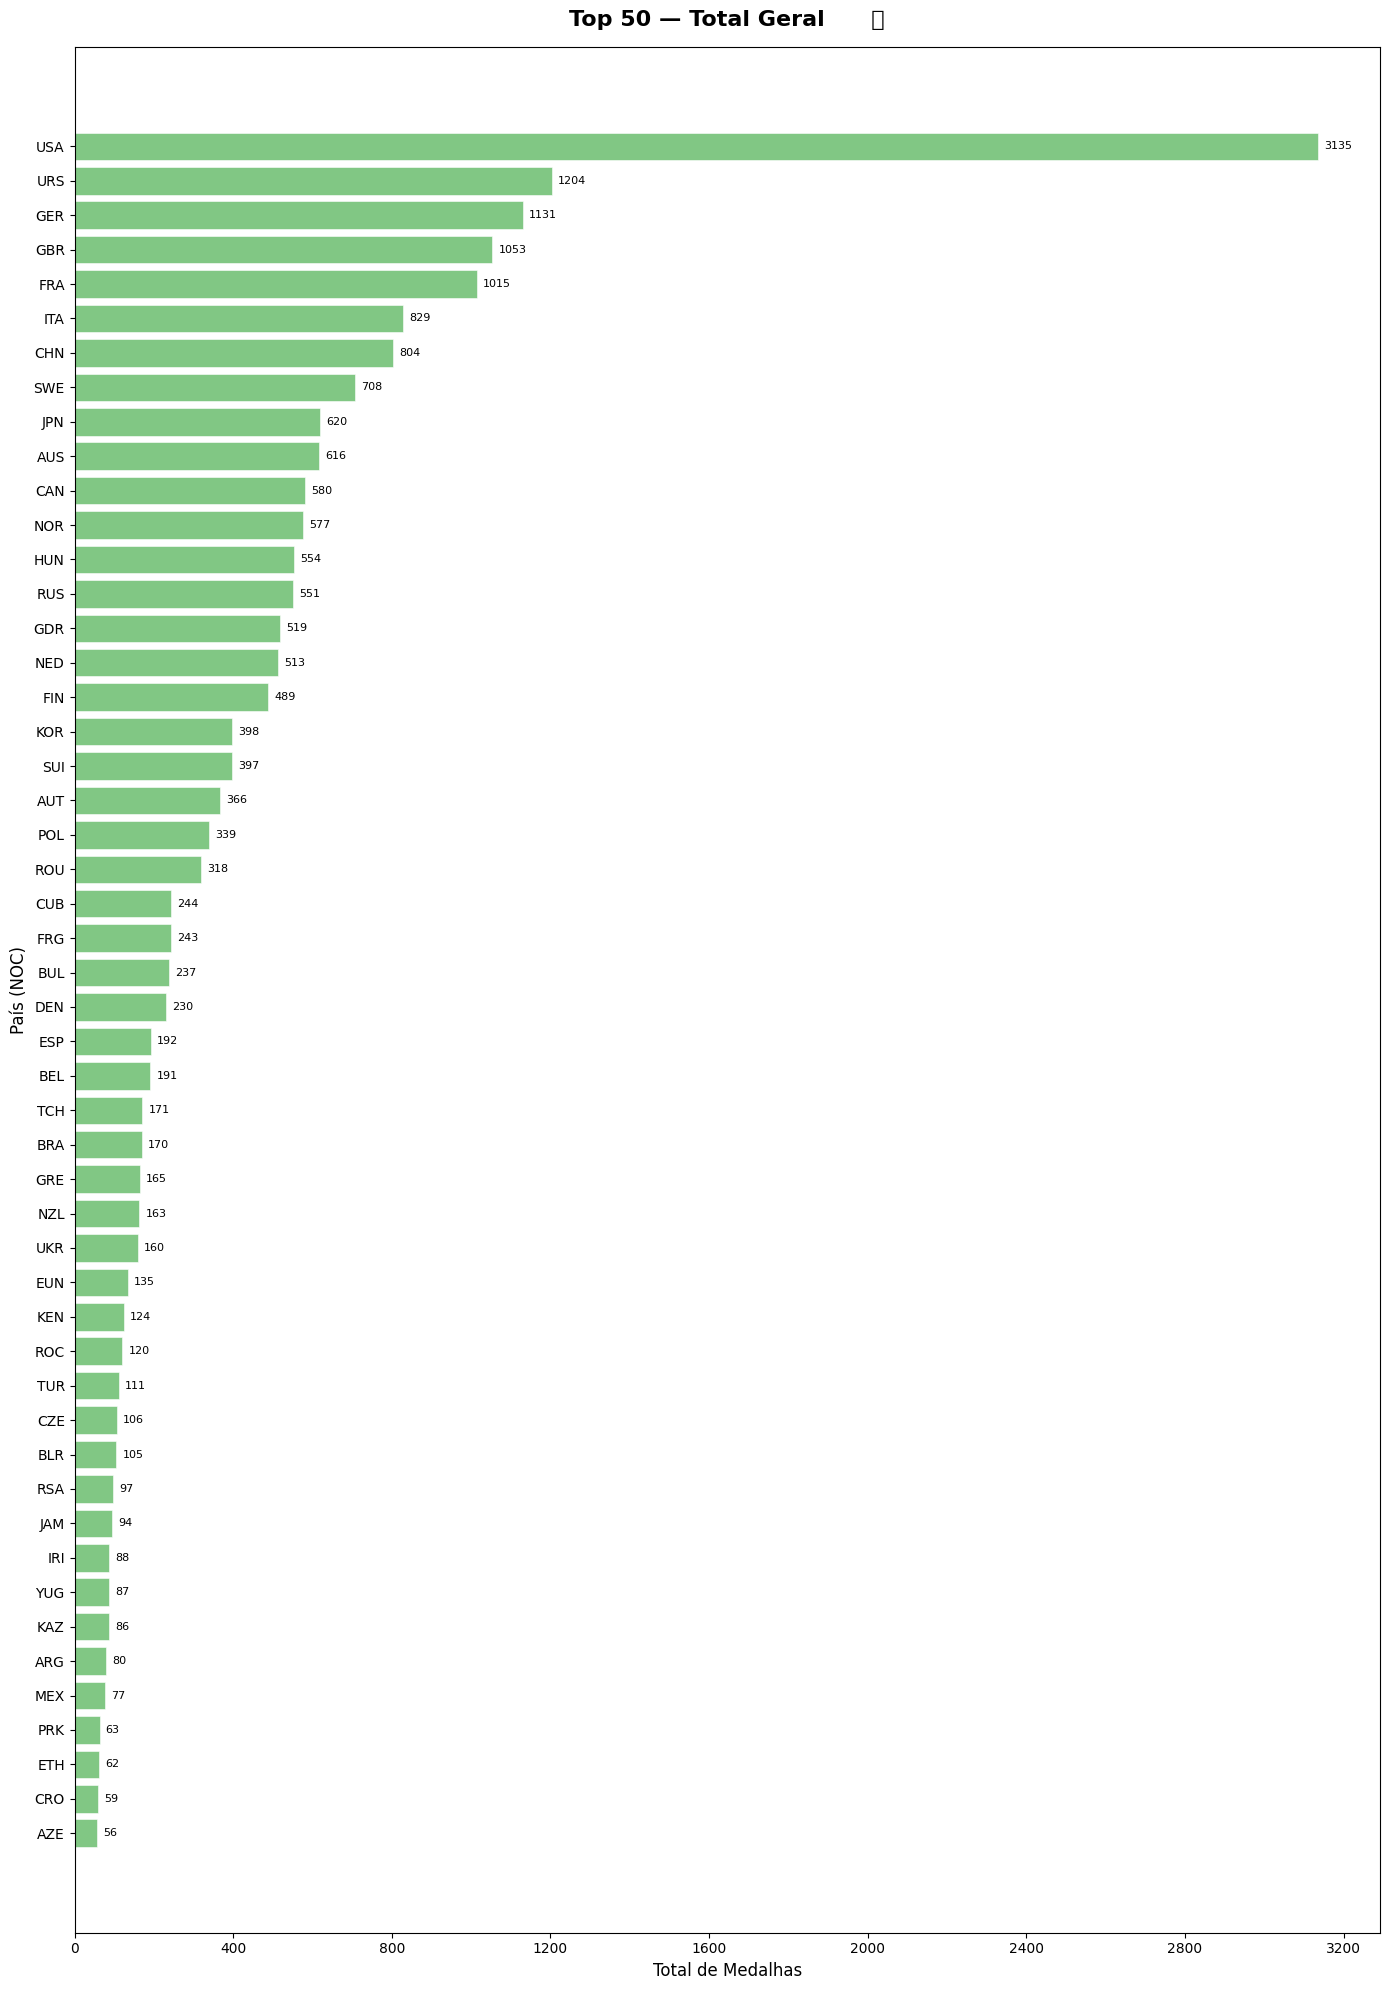

✅ Gráfico salvo: olympics-datalake/gold/analise_medalhas/top50_total.png


In [ ]:
# ── Gráficos Top 50 ───────────────────────────────────
def plot_top50(df_rank, titulo, cor, nome_arquivo, pasta):
    top50 = df_rank.head(50).iloc[::-1]
    fig, ax = plt.subplots(figsize=(14, 20))
    ax.barh(top50['NOC'], top50['Total'], color=cor, edgecolor='white', linewidth=0.4)
    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Total de Medalhas', fontsize=12)
    ax.set_ylabel('País (NOC)', fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    max_val = top50['Total'].max()
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(w + max_val*0.005, bar.get_y()+bar.get_height()/2,
                str(int(w)), va='center', ha='left', fontsize=8)
    plt.tight_layout()
    caminho = pasta / nome_arquivo
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Gráfico salvo: {caminho}')

plot_top50(tbl_summer, 'Top 50 — Jogos de Verão  ☀️',  '#FFD700', 'top50_verao.png',   GOLD_MED)
plot_top50(tbl_winter, 'Top 50 — Jogos de Inverno ❄️', '#4FC3F7', 'top50_inverno.png', GOLD_MED)
plot_top50(tbl_total,  'Top 50 — Total Geral      🏅',  '#81C784', 'top50_total.png',   GOLD_MED)

### 5.2 Análise por Gênero

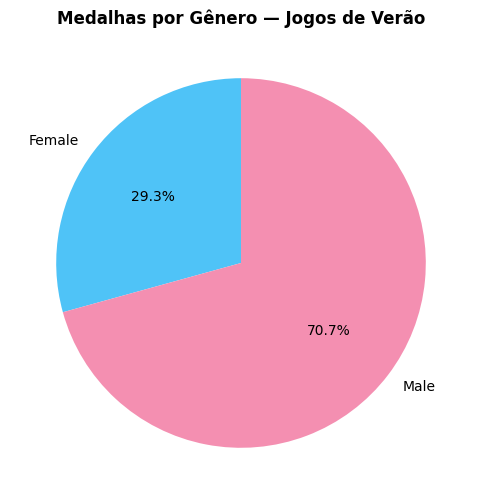

✅ Gráfico salvo: olympics-datalake/gold/analise_genero/genero_summer.png


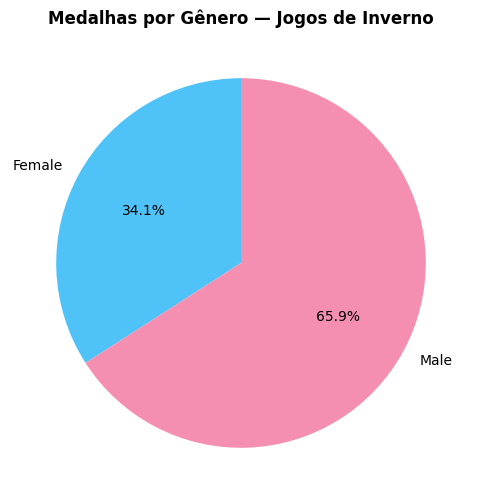

✅ Gráfico salvo: olympics-datalake/gold/analise_genero/genero_winter.png
✅ analise_genero.csv salvo


In [ ]:
GOLD_GEN = ROOT / 'gold' / 'analise_genero'

# Participação histórica por sexo e edição
df_genero = (
    df_results_enrich[df_results_enrich['medal'].notna()]
    .groupby(['season', 'sex'])['athlete_id']
    .count()
    .reset_index()
    .rename(columns={'athlete_id': 'total_medalhas'})
)

# Gráfico de pizza por gênero
for season in ['Summer', 'Winter']:
    df_s = df_genero[df_genero['season'] == season]
    if not df_s.empty:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.pie(df_s['total_medalhas'], labels=df_s['sex'],
               autopct='%1.1f%%', colors=['#4FC3F7','#F48FB1'], startangle=90)
        ax.set_title(f'Medalhas por Gênero — Jogos de {"Verão" if season=="Summer" else "Inverno"}',
                     fontweight='bold')
        caminho = GOLD_GEN / f'genero_{season.lower()}.png'
        plt.savefig(caminho, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Gráfico salvo: {caminho}')

df_genero.to_csv(GOLD_GEN / 'analise_genero.csv', index=False)
print('✅ analise_genero.csv salvo')

### 5.3 Análise de Modalidades (Paris 2024)

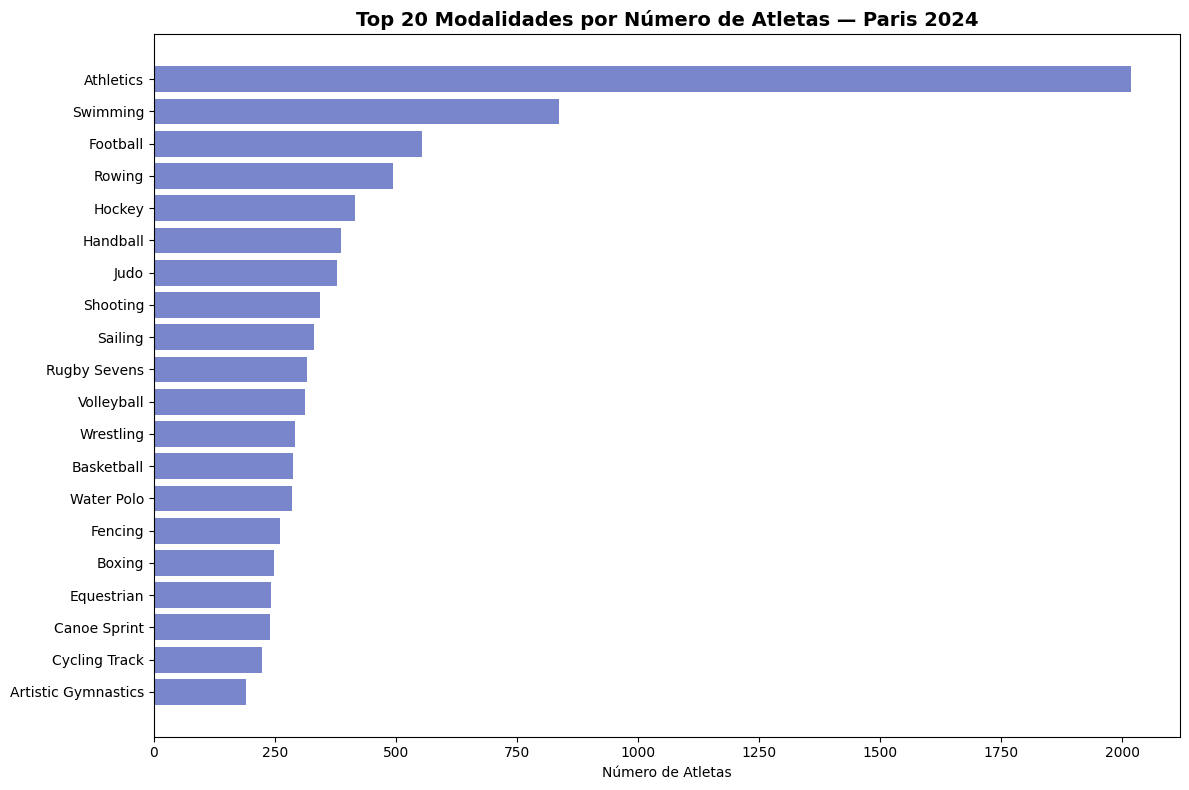

✅ Gráfico e CSV de modalidades salvos


In [ ]:
GOLD_MOD = ROOT / 'gold' / 'analise_modalidades'

# Top modalidades por número de atletas em Paris 2024
df_mod = (
    df_atletas_eventos[df_atletas_eventos['sport_principal'].notna()]
    .groupby('sport_principal')['athlete_id']
    .count()
    .reset_index()
    .rename(columns={'sport_principal': 'Modalidade', 'athlete_id': 'Atletas'})
    .sort_values('Atletas', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_mod['Modalidade'].iloc[::-1], df_mod['Atletas'].iloc[::-1], color='#7986CB')
ax.set_title('Top 20 Modalidades por Número de Atletas — Paris 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Atletas')
plt.tight_layout()
caminho_mod = GOLD_MOD / 'top20_modalidades_paris2024.png'
plt.savefig(caminho_mod, dpi=150, bbox_inches='tight')
plt.show()

df_mod.to_csv(GOLD_MOD / 'modalidades_paris2024.csv', index=False)
print(f'✅ Gráfico e CSV de modalidades salvos')

In [ ]:
# ── Salvar CSVs finais da camada gold/ ────────────────
df_quadro.to_csv(    GOLD_MED / 'medalhas_summary.csv', index=False)
tbl_summer.to_csv(   GOLD_MED / 'medalhas_verao.csv',   index=False)
tbl_winter.to_csv(   GOLD_MED / 'medalhas_inverno.csv', index=False)
tbl_total.to_csv(    GOLD_MED / 'medalhas_total.csv',   index=False)
print('✅ CSVs gold/analise_medalhas/ salvos')

✅ CSVs gold/analise_medalhas/ salvos


In [ ]:
# ── Metadados gold/ ───────────────────────────────────
meta_gold = {
    'nome_dataset'       : 'quadro_medalhas_olimpicas',
    'descricao'          : 'Quadro consolidado de medalhas olímpicas 1896–2024, compatível com o formato Wikipédia.',
    'fontes_origem'      : ['bronze/medalhas_1896_2024.parquet'],
    'operacao'           : 'groupby NOC + join Summer × Winter',
    'arquivos_gerados'   : [
        'medalhas_summary.csv', 'medalhas_verao.csv', 'medalhas_inverno.csv', 'medalhas_total.csv',
        'top50_verao.png', 'top50_inverno.png', 'top50_total.png'
    ],
    'periodo_coberto'    : '1896–2024',
    'data_processamento' : str(date.today()),
    'camada'             : 'gold',
    'versao'             : '1.0',
}
with open(GOLD_MED / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta_gold, f, ensure_ascii=False, indent=4)
print('✅ metadata.json gold/ salvo')

✅ metadata.json gold/ salvo


## 6. README.md e metadata_schema.json

In [ ]:
readme = '''# 🏅 Olympics Data Lake (1896–2024)

Data Lake local com **6 datasets** cobrindo os Jogos Olímpicos de 1896 a 2024.

## Fontes

| Dataset | Fonte | Período |
|---------|-------|---------|
| `hist_athlete_bio` | Base dos Dados / Olympedia | 1896–2022 |
| `hist_athlete_event_result` | Base dos Dados / Olympedia | 1896–2022 |
| `hist_game_medal_tally` | Base dos Dados / Olympedia | 1896–2022 |
| `paris2024_athletes` | Kaggle — Paris 2024 | 2024 |
| `paris2024_events` | Kaggle — Paris 2024 | 2024 |
| `paris2024_medals_total` | Kaggle — Paris 2024 | 2024 |

## Estrutura

```
olympics-datalake/
├── README.md
├── metadata_schema.json
├── raw/                             # CSVs brutos + metadados JSON
├── bronze/                          # Parquet padronizados + JOINs
│   ├── medalhas_1896_2024           # UNION histórico + Paris 2024
│   ├── resultados_enriquecidos      # Resultados + bio dos atletas
│   └── atletas_paris2024_eventos    # Atletas Paris + catálogo de eventos
└── gold/
    ├── analise_medalhas/            # Quadro final + gráficos Top 50
    ├── analise_atletas/
    ├── analise_modalidades/         # Top modalidades Paris 2024
    └── analise_genero/              # Distribuição por gênero
```

## Pipeline

```
raw/ (CSV brutos + JSON)  →  bronze/ (Parquet + JOINs)  →  gold/ (análises + gráficos)
```

## Aluno

Daniel Nazário Oliveira de Souza — Sistemas de Informação, UEA
Professor: Luis Cueves Rodriguez
'''

with open(ROOT / 'README.md', 'w', encoding='utf-8') as f:
    f.write(readme)
print('✅ README.md criado')

✅ README.md criado


In [ ]:
schema = {
    'schema_version' : '1.0',
    'descricao'      : 'Esquema padrão de metadados deste Data Lake. Todo arquivo de dados possui um .json correspondente.',
    'campos_obrigatorios': [
        {'campo': 'nome_dataset',      'tipo': 'string', 'descricao': 'Identificador único'},
        {'campo': 'descricao',         'tipo': 'string', 'descricao': 'Descrição legível'},
        {'campo': 'fonte',             'tipo': 'string', 'descricao': 'URL ou referência de origem'},
        {'campo': 'campos_principais', 'tipo': 'array',  'descricao': 'Lista de colunas com nome, tipo e descrição'},
        {'campo': 'data_coleta',       'tipo': 'string', 'descricao': 'Data YYYY-MM-DD'},
        {'campo': 'formato',           'tipo': 'string', 'descricao': 'CSV / Parquet / JSON'},
        {'campo': 'camada',            'tipo': 'string', 'descricao': 'raw | bronze | gold'},
        {'campo': 'versao',            'tipo': 'string', 'descricao': 'Versão do dataset'},
    ],
    'campos_opcionais': [
        {'campo': 'fontes_origem',   'descricao': 'Datasets de origem (bronze e gold)'},
        {'campo': 'operacao',        'descricao': 'Transformação aplicada (JOIN, UNION, GROUP BY...)'},
        {'campo': 'periodo_coberto', 'descricao': 'Intervalo temporal'},
        {'campo': 'observacoes',     'descricao': 'Notas adicionais'},
    ],
    'camadas': {
        'raw'   : 'Dados brutos sem transformação',
        'bronze': 'Dados padronizados, tipados e integrados (Parquet)',
        'gold'  : 'Dados prontos para análise, agregados e com visualizações',
    }
}
with open(ROOT / 'metadata_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, ensure_ascii=False, indent=4)
print('✅ metadata_schema.json criado')

✅ metadata_schema.json criado


## 7. Visão Final e Download

In [ ]:
print('📁 Estrutura final do Data Lake:\n')
for root, dirs, files_list in os.walk(ROOT):
    nivel = root.replace(str(ROOT), '').count(os.sep)
    print('│   ' * nivel + '├── ' + os.path.basename(root) + '/')
    for filename in sorted(files_list):
        tam = os.path.getsize(Path(root) / filename)
        unidade = f'{tam//1024} KB' if tam >= 1024 else f'{tam} B'
        print('│   ' * (nivel+1) + '├── ' + filename + f'  ({unidade})')

📁 Estrutura final do Data Lake:

├── olympics-datalake/
│   ├── README.md  (1 KB)
│   ├── metadata_schema.json  (1 KB)
│   ├── bronze/
│   │   ├── atletas_paris2024_eventos.csv  (865 KB)
│   │   ├── atletas_paris2024_eventos.json  (610 B)
│   │   ├── atletas_paris2024_eventos.parquet  (324 KB)
│   │   ├── hist_athlete_bio.parquet  (24610 KB)
│   │   ├── hist_athlete_event_result.parquet  (5425 KB)
│   │   ├── hist_game_medal_tally.parquet  (20 KB)
│   │   ├── medalhas_1896_2024.csv  (108 KB)
│   │   ├── medalhas_1896_2024.json  (655 B)
│   │   ├── medalhas_1896_2024.parquet  (21 KB)
│   │   ├── paris2024_athletes.parquet  (3094 KB)
│   │   ├── paris2024_events.parquet  (8 KB)
│   │   ├── paris2024_medals_total.parquet  (9 KB)
│   │   ├── resultados_enriquecidos.csv  (40796 KB)
│   │   ├── resultados_enriquecidos.json  (664 B)
│   │   ├── resultados_enriquecidos.parquet  (6218 KB)
│   ├── raw/
│   │   ├── hist_athlete_bio.csv  (54206 KB)
│   │   ├── hist_athlete_bio.json  (2 KB)
│   │  

In [26]:
# Compactar e baixar
shutil.make_archive('olympics-datalake', 'zip', '.', 'olympics-datalake')
print('✅ olympics-datalake.zip gerado!')

from google.colab import files
files.download('olympics-datalake.zip')

✅ olympics-datalake.zip gerado!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>